In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("student-mat.csv", sep=";")
print(np.sum(df.isnull().sum()))
print(np.sum(df.isna().sum()))
print(np.sum(df.duplicated().sum()))

df.info()
#df[df.dtype == np.dtype("str")]
df.dtypes


0
0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  high

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [2]:
# obj_feats = np.array(df.loc[: , df.dtypes == 'object'].columns)
# df_1 = df.copy()

# for f in obj_feats:
#   df_1[f] = df[f].astype('category')

# np.sum(df_1.dtypes == np.dtype('object'))

# df_1.info()

df_1 = pd.concat([df.select_dtypes(include='object'), df[["G1", "G2", "G3"]]], axis=1)
df_1



,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,G1,G2,G3
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no,5,6,6
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no,5,5,6
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,yes,no,yes,yes,yes,no,7,8,10
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes,yes,yes,15,14,15
4,GP,F,U,GT3,T,other,other,home,father,no,yes,yes,no,yes,yes,no,no,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,U,LE3,A,services,services,course,other,no,yes,yes,no,yes,yes,no,no,9,9,9
391,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no,14,16,16
392,MS,M,R,GT3,T,other,other,course,other,no,no,no,no,no,yes,no,no,10,8,7
393,MS,M,R,LE3,T,services,other,course,mother,no,no,no,no,no,yes,yes,no,11,12,10


In [3]:
df_1['internet'].value_counts()
df_1['paid'].value_counts()


,count
paid,
no,214
yes,181


<Axes: >

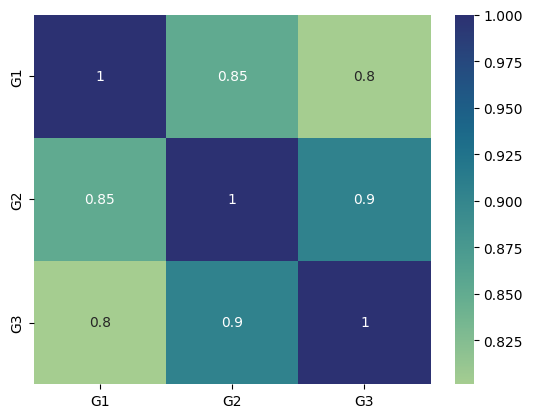

In [4]:
import seaborn as sns

sns.heatmap(df_1[["G1", "G2", "G3"]].corr(), annot=True, cmap="crest")

In [5]:
# df_1["G1"].value_counts().reset_index()["G1"].sort_values()
# df_1["G3"].value_counts().sort_values().plot(kind="bar")
# display(df_1["G1"].describe())
# display(df_1["G2"].describe())
# display(df_1["G3"].describe())

for r in range(22):
  print(f"{r}: {df_1["G1"].isin(range(r)).sum()}")

0: 0
1: 0
2: 0
3: 0
4: 1
5: 2
6: 9
7: 33
8: 70
9: 111
10: 142
11: 193
12: 232
13: 267
14: 300
15: 330
16: 354
17: 376
18: 384
19: 392
20: 395
21: 395


<Axes: >

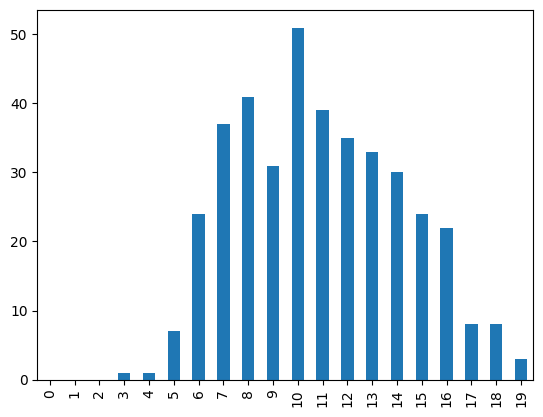

In [6]:
g1_bins = np.bincount(df_1["G1"].values)
s_bins = pd.Series(g1_bins, index=range(20))

s_vals = pd.Series(df_1["G1"].values)

s_bins.plot(kind='bar')

In [7]:
# Now let's encode our categorical features with OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

#['Mjob','Fjob','studytime','sex']
def oh_encoder(X, features):
    for f in features:
      ohe = OneHotEncoder()
      encoded = ohe.fit_transform(X[[f]]).toarray()
      df_encoded_feature = pd.DataFrame(encoded, columns=[f"{f}_{cat}" for cat in ohe.categories_[0] ])

      X = pd.concat([X, df_encoded_feature], axis=1)


    return X





In [8]:
X = df_1.copy().drop(["G1", "G2", "G3"], axis=1)
y = df_1[["G1", "G2", "G3"]]
X = X.select_dtypes(include='object').astype('category')
#X.replace(np.object_, 'category')
categorical_features = X[[col for col in X.columns if X[col].dtype == 'category']].columns.tolist()
categorical_features
X_cat = oh_encoder(X, categorical_features)
X_cat.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   school             395 non-null    category
 1   sex                395 non-null    category
 2   address            395 non-null    category
 3   famsize            395 non-null    category
 4   Pstatus            395 non-null    category
 5   Mjob               395 non-null    category
 6   Fjob               395 non-null    category
 7   reason             395 non-null    category
 8   guardian           395 non-null    category
 9   schoolsup          395 non-null    category
 10  famsup             395 non-null    category
 11  paid               395 non-null    category
 12  activities         395 non-null    category
 13  nursery            395 non-null    category
 14  higher             395 non-null    category
 15  internet           395 non-null    category
 16  romantic

In [9]:
xhold = df_1.copy()
xhold.select_dtypes(include='object').astype('category').dtypes
X_cat['school_GP']
X_cat.drop(X_cat.select_dtypes(include='category').columns,axis=1)

,school_GP,school_MS,sex_F,sex_M,address_R,address_U,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
391,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
392,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
393,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      395 non-null    category
 1   sex         395 non-null    category
 2   address     395 non-null    category
 3   famsize     395 non-null    category
 4   Pstatus     395 non-null    category
 5   Mjob        395 non-null    category
 6   Fjob        395 non-null    category
 7   reason      395 non-null    category
 8   guardian    395 non-null    category
 9   schoolsup   395 non-null    category
 10  famsup      395 non-null    category
 11  paid        395 non-null    category
 12  activities  395 non-null    category
 13  nursery     395 non-null    category
 14  higher      395 non-null    category
 15  internet    395 non-null    category
 16  romantic    395 non-null    category
dtypes: category(17)
memory usage: 9.0 KB


In [11]:
# df_1_num = df_1.select_dtypes(include=[np.number]).drop(['G1', 'G2', 'G3'],axis=1)
# X = pd.concat([X,df_1_num],axis=1)
# X.iloc[: , 5:20].head(5)
# X

In [12]:
# X[X['absences'] == 'GP']

X0 = X.drop(X.select_dtypes(include='category'), axis=1)
X0.info()

# X_floats = X0.select_dtypes(include=[np.float64])
# encoded_columns = X_floats.columns.values
# encoded_columns
X_cat_encoded = X_cat.drop([col for col in X_cat.columns if X_cat[col].dtype == 'category'], axis=1)
X_cat_encoded
X0
np.all((X_cat.drop([col for col in X_cat.columns if X_cat[col].dtype == 'category'], axis=1)\
 == X_cat.drop(X_cat.select_dtypes(include='category'), axis=1)).sum(), axis=0)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Empty DataFrame


np.True_

In [13]:
numeric_columns = list(df.select_dtypes(include=[np.int64]).columns)
numeric_columns
X_int = df.select_dtypes(include=np.int64).drop(["G1", "G2", "G3"], axis=1)
X_int


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
0,18,4,4,2,2,0,4,3,4,1,1,3,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4
2,15,1,1,1,2,3,4,3,2,2,3,3,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2
4,16,3,3,1,2,0,4,3,2,1,2,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,2,1,2,2,5,5,4,4,5,4,11
391,17,3,1,2,1,0,2,4,5,3,4,2,3
392,21,1,1,1,1,3,5,5,3,3,3,3,3
393,18,3,2,3,1,0,4,4,1,3,4,5,0


In [60]:
# yg1 = y['G1']
# yg1[y['G1'] ==12].count()
# drop = np.array(yg1[yg1== 12].index)
from sklearn.metrics import accuracy_score, f1_score

In [15]:
X0 = pd.concat([X_cat_encoded, X_int], axis=1)

In [16]:
s1 = 0
s2 = 0
len(X0)
y['G1'].value_counts().sort_values(ascending=False)
y['G1'].value_counts().sort_values()

,count
G1,
4,1
3,1
19,3
5,7
17,8
18,8
16,22
6,24
15,24


In [17]:
df_new = df_1.select_dtypes(include='object').astype('category')
for f in df_new.columns:
  df_new[f] = df_new[f].cat.codes
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int8 
 1   sex         395 non-null    int8 
 2   address     395 non-null    int8 
 3   famsize     395 non-null    int8 
 4   Pstatus     395 non-null    int8 
 5   Mjob        395 non-null    int8 
 6   Fjob        395 non-null    int8 
 7   reason      395 non-null    int8 
 8   guardian    395 non-null    int8 
 9   schoolsup   395 non-null    int8 
 10  famsup      395 non-null    int8 
 11  paid        395 non-null    int8 
 12  activities  395 non-null    int8 
 13  nursery     395 non-null    int8 
 14  higher      395 non-null    int8 
 15  internet    395 non-null    int8 
 16  romantic    395 non-null    int8 
dtypes: int8(17)
memory usage: 6.7 KB


In [23]:

from sklearn.utils import compute_class_weight
y = df_1[["G1", "G2", "G3"]].copy()
y.info()

y["G1"].describe(percentiles=[.1, .9])
# np.percentile(y['G1'].values, 10,method='inverted_cdf', weights=np.bincount(y['G1'].values), axis=1)
s_bins.quantile([.2,.8], interpolation='nearest')
counted_df = y['G1'].value_counts().sort_values(ascending=False).reset_index()
counted_df.groupby('G1')['count'].quantile()
arr = np.append(np.array([0, 1, 2]),np.unique(y["G1"]))
np.arange(21)
cw = compute_class_weight(class_weight="balanced", classes=np.unique(y['G1']), y=y['G1'])
s_weights = pd.Series(cw, index=np.unique(y['G1']))
dict_weights = [{0:1, 1:round(val)} if val >1 else {0:1, 1:1} for val in s_weights]
dict_weights
d_w = dict(zip(np.unique(y['G1']), np.ceil(cw).astype(int))) #apparently this might be correct usage for RandomForestClassifier's class_weights parameter
d_w


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   G1      395 non-null    int64
 1   G2      395 non-null    int64
 2   G3      395 non-null    int64
dtypes: int64(3)
memory usage: 9.4 KB


{np.int64(3): np.int64(24),
 np.int64(4): np.int64(24),
 np.int64(5): np.int64(4),
 np.int64(6): np.int64(1),
 np.int64(7): np.int64(1),
 np.int64(8): np.int64(1),
 np.int64(9): np.int64(1),
 np.int64(10): np.int64(1),
 np.int64(11): np.int64(1),
 np.int64(12): np.int64(1),
 np.int64(13): np.int64(1),
 np.int64(14): np.int64(1),
 np.int64(15): np.int64(1),
 np.int64(16): np.int64(2),
 np.int64(17): np.int64(3),
 np.int64(18): np.int64(3),
 np.int64(19): np.int64(8)}

In [81]:
X_new = pd.concat([df_new, X_int,y['G1']], axis=1)
minorities = X_new[(X_new['G1'] < 6) | (X_new['G1'] > 15)]
minorities_2 = pd.concat([minorities]*4, ignore_index=True)
X_shuffled = pd.concat([X_new, minorities_2]).reset_index(drop=True).sample(frac=1).reset_index(drop=True)

y_new = X_shuffled['G1']
X_shuffled = X_shuffled.drop(['G1'],axis=1)
X_shuffled
y_new

,G1
0,6
1,14
2,6
3,16
4,9
...,...
590,19
591,16
592,10
593,7


In [94]:
#!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from collections import Counter


oversample = SMOTE(k_neighbors=4)
X_oversample, y_oversample = oversample.fit_resample(X_shuffled, y_new)
X_oversample
y_oversample
counter = Counter(y_oversample)
counter




,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [105]:
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

depth = 30


for d in range(1, depth+1):
  X_train, X_test, y_train, y_test = train_test_split(X_oversample, y_oversample,test_size=0.3, random_state=42)

  dtc = DecisionTreeClassifier(max_depth=d, random_state=42)
  rfc = RandomForestClassifier(max_depth=d, n_estimators=1000, random_state=42, warm_start=True, oob_score=True)
  gbc = GradientBoostingClassifier(max_depth=d,n_estimators=1000,learning_rate=.11, random_state=42)

  # dtc.fit(X_train, y_train)
  rfc.fit(X_train, y_train)
  gbc.fit(X_train, y_train)

  # dtc_test_prediction = dtc.predict(X_test)
  rfc_test_prediction = rfc.predict(X_test)
  gbc_test_prediction = gbc.predict(X_test)


  # dtc_accuracy = accuracy_score(y_test, dtc_test_prediction)
  rfc_accuracy = accuracy_score(y_test, rfc_test_prediction)
  gbc_accuracy = accuracy_score(y_test, gbc_test_prediction)

  print(f"At Depth: {d}")
  # print(f"DecisionTreeClassifier Accuracy: {dtc_accuracy}")
  print(f"RandomForestClassifier Accuracy: {rfc_accuracy}")
  print(f"GradientBoostedClassifier Accuracy: {gbc_accuracy}")



  # if d == 3:
  #   #print(f"GradientBoostingClassifier Feature Importance: {gbc.feature_importances_}")
  #   s1 = pd.Series(gbc.feature_importances_, index=X0.columns)
  # if d == 4:
  #   s2 = pd.Series(gbc.feature_importances_, index=X0.columns)


At Depth: 1
RandomForestClassifier Accuracy: 0.21746880570409982
RFC OOB_Score: 0.20244461420932008
At Depth: 2
RandomForestClassifier Accuracy: 0.35294117647058826
RFC OOB_Score: 0.3116883116883117
At Depth: 3
RandomForestClassifier Accuracy: 0.5026737967914439
RFC OOB_Score: 0.46294881588999237
At Depth: 4
RandomForestClassifier Accuracy: 0.5953654188948306
RFC OOB_Score: 0.5752482811306341
At Depth: 5
RandomForestClassifier Accuracy: 0.6755793226381461
RFC OOB_Score: 0.6730328495034378
At Depth: 6
RandomForestClassifier Accuracy: 0.7575757575757576
RFC OOB_Score: 0.7478991596638656
At Depth: 7
RandomForestClassifier Accuracy: 0.8021390374331551
RFC OOB_Score: 0.7853323147440795
At Depth: 8
RandomForestClassifier Accuracy: 0.8360071301247772
RFC OOB_Score: 0.8242933537051184
At Depth: 9
RandomForestClassifier Accuracy: 0.8609625668449198
RFC OOB_Score: 0.8502673796791443
At Depth: 10
RandomForestClassifier Accuracy: 0.8770053475935828
RFC OOB_Score: 0.8640183346065698
At Depth: 11
Ra

<font face="Serif" size=11 color='#d39aed'>

- 7:04PM 3/9/26

The RandomForestClassifier and GradientBoostedClassifier have finally breached 90% in accuracy score. Using imblearn's SMOTE() class to synthetically augment my self-made already oversampled dataset further is what got the models to this point. Before this, GradientBoosting barely breached 50% and RandomForestClassifier I think breached that accuracy score only once.
These are the parameters for this run's success:

```
  rfc = RandomForestClassifier(max_depth=d, n_estimators=100)
  gbc = GradientBoostingClassifier(max_depth=d,n_estimators=1000,learning_rate=.11)
```
GradientBoostingClassifier Top Accuracy Score: 0.9010695187165776 @ Depth 7

RandomForestClassifier Top Accuracy Score: 0.9278074866310161 @ Depth 15

The models were looped through depth values 1 to 15. At depth 7, GradientBoostingClassifier reached its peak value and descended without stopping afterwards. RandomForestClassifier on the other hand went upward continuously with the only exception at depth 10, where it had an accuracy score drop of under 1 point.

### At Depth: 1
*RandomForestClassifier Accuracy: 0.26737967914438504*

*GradientBoostedClassifier Accuracy: 0.6657754010695187*


## Run 2

```
  X_train, X_test, y_train, y_test = train_test_split(X_oversample, y_oversample,test_size=0.3, random_state=42)

  dtc = DecisionTreeClassifier(max_depth=d, random_state=42)
  rfc = RandomForestClassifier(max_depth=d, n_estimators=1000, random_state=42)
  gbc = GradientBoostingClassifier(max_depth=d,n_estimators=700,learning_rate=.11, random_state=42)
```

For this run the number of estimators was increased to 1000 for RFC and decreased to 700 for GBC. The test_size was slightly increased to 0.3.

RandomForestClassifier Top Accuracy Score: 0.9037433155080213 @ Depth 15
GradientBoostingClassifier Top Accuracy Score: 0.8859180035650623 @ Depth 6

The most interesting observation on this run was that GBC did begin to descend after its peak but it seemed to stop descending, or stabilizing, at around depth 12. It never went up by more than point but nor did it go down by more than that. I will run this again with 1000 learners for GBC and the same test size.

I've run it again with 1000 learners for GBC and the same happened.
I've run it again with 1300 learners this time and the same happened.

<font>


In [ ]:
s1_top_features = s1.sort_values(ascending=False).iloc[0:28]
s2_top_features = s2.sort_values(ascending=False).iloc[0:28]
s2_top_features.index.tolist()

s2_top_features

In [ ]:
from itertools import combinations


#numeric_columns
#encoded_columns
features = numeric_columns
results = []
max_accuracy = 0
max_arr = []
k = 1


for r in range(len(features) + 1):
    results.extend(combinations(features, r))


for feats in results:
    feats = list(feats)
    if not feats:
        continue

    X_train, X_test, y_train, y_test = train_test_split(X0.loc[: ,list(encoded_columns) + feats], y['G1'].values, test_size=0.2, random_state=42)

    dt = GradientBoostingClassifier(n_estimators=30, max_depth=5)
    dt.fit(X_train, y_train)
    y_test_prediction = dt.predict(X_test)
    accuracy = np.sum(y_test == y_test_prediction)/len(y_test)



    if accuracy > max_accuracy:
      max_accuracy = accuracy
      max_arr = [f"{feats}: ' {max_accuracy}"]




print(max_arr)

The cell above runs a sequence of decision tree predictions on our dataset of encoded columns concatenated to a secquence of different combinations of the numeric columns.

Run 1:
* max_depth = 2

* ['failures', 'Walc']

* *accuracy: 0.34177215189873417*



Run 2:

* max_depth = 5

* ['Medu', 'traveltime', 'studytime', 'famrel', 'freetime', 'absences']

* *accuracy: 0.45569620253164556*


Run 3:
* max_depth = 12

* ['traveltime', 'studytime', 'absences']

* *accuracy: 0.5063291139240507*

Run 4:
* max_depth = 20

* ['age', 'Fedu', 'failures', 'famrel', 'absences']

* *accuracy: 0.4936708860759494*

Run 5:

* max_depth = 15

* ['age', 'Medu', 'traveltime', 'failures', 'Dalc', 'Walc', 'absences']

* *accuracy: 0.5316455696202531*

In [ ]:
import DecisionTree

